In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/DanhBitoo/Clustering-for-Credit-Card-Customers/refs/heads/main/BankChurners_Final.csv')
print("Shape:", df.shape)
df.head()

Shape: (10127, 24)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Last_Activity_Date
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991,2023-01-04
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994,2023-01-01
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998,2023-01-01
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987,2023-04-03
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998,2023-01-03


<span style="font-family: monospace; font-size: 6mm;">

Remove Naive Bayes Classifiers and `CLIENTNUM` column
</span>

In [2]:
df.drop(['CLIENTNUM',
         'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 
         'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'], axis=1, inplace=True)

In [3]:
df['Last_Activity_Date'] = pd.to_datetime(df['Last_Activity_Date'], format='%Y-%m-%d')

<span style="font-family: monospace; font-size: 6mm;">
Basic info
</span>

In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Attrition_Flag            10127 non-null  object        
 1   Customer_Age              10127 non-null  int64         
 2   Gender                    10127 non-null  object        
 3   Dependent_count           10127 non-null  int64         
 4   Education_Level           10127 non-null  object        
 5   Marital_Status            10127 non-null  object        
 6   Income_Category           10127 non-null  object        
 7   Card_Category             10127 non-null  object        
 8   Months_on_book            10127 non-null  int64         
 9   Total_Relationship_Count  10127 non-null  int64         
 10  Months_Inactive_12_mon    10127 non-null  int64         
 11  Contacts_Count_12_mon     10127 non-null  int64         
 12  Credit_Limit      

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Last_Activity_Date
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,2023-02-23 19:59:32.983114496
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,2023-01-01 00:00:00
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,2023-02-03 00:00:00
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,2023-02-25 00:00:00
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,2023-03-15 00:00:00
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,2023-06-28 00:00:00
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,NaN


<span style="font-family: monospace; font-size: 6mm;">

#### **Feature Engineering Steps**

1. **Interaction Features** - combining existing features
2. **Ratio Features** - (perhaps meaningful?) ratios between features
3. **Binning Features** - categorizing continuous variables
4. **Polynomial Features** - for non-linear relationships
5. **Date Features** - extracting time information
6. **Aggregation Features** - statistical aggregations
7. **Behavioral Features** - regarding users activeness (and to detect risk maybe?)
8. **Domain-specific Features**

In [5]:
df_fe = df.copy()

<span style="font-family: monospace; font-size: 6mm;">

**1. Interaction Features**

In [6]:
df_fe['Credit_Per_Transaction'] = df_fe['Credit_Limit'] / (df_fe['Total_Trans_Ct'] + 1)

df_fe['Avg_Transaction_Amt'] = df_fe['Total_Trans_Amt'] / (df_fe['Total_Trans_Ct'] + 1)

df_fe['Spending_To_Limit'] = df_fe['Total_Trans_Amt'] / (df_fe['Credit_Limit'] + 1)

df_fe['Relationship_Strength'] = df_fe['Total_Relationship_Count'] * df_fe['Months_on_book']

df_fe['Activity_Score'] = (12 - df_fe['Months_Inactive_12_mon']) * df_fe['Total_Trans_Ct']

df_fe['Engagement_Index'] = df_fe['Total_Trans_Ct'] * df_fe['Contacts_Count_12_mon']

df_fe[['Credit_Per_Transaction', 'Avg_Transaction_Amt', 'Spending_To_Limit', 
       'Relationship_Strength', 'Activity_Score', 'Engagement_Index']].head()

,Credit_Per_Transaction,Avg_Transaction_Amt,Spending_To_Limit,Relationship_Strength,Activity_Score,Engagement_Index
0,295.139535,26.604651,0.090136,195,462,126
1,242.823529,37.970588,0.156352,264,363,66
2,162.761905,89.857143,0.551916,144,220,0
3,157.761905,55.761905,0.353349,102,160,20
4,162.620690,28.137931,0.172991,105,308,0


<span style="font-family: monospace; font-size: 5mm;">

**Legend**

`Credit_Per_Transaction`: Credit utilization per transaction <br>
`Avg_Transaction_Amt`: Average transaction amount <br>
`Spending_To_Limit`: Spending to limit ratio <br>
`Relationship_Strength`: Relationship strength indicator <br>
`Activity_Score`: Activity score (inverse of inactivity) <br>
`Engagement_Index`: Customer engagement <br>


<span style="font-family: monospace; font-size: 6mm;">

**2. Ratio Features**

In [7]:
df_fe['Balance_To_Limit'] = df_fe['Total_Revolving_Bal'] / (df_fe['Credit_Limit'] + 1)

df_fe['Open_To_Buy_Ratio'] = df_fe['Avg_Open_To_Buy'] / (df_fe['Credit_Limit'] + 1)

df_fe['Transaction_Frequency'] = df_fe['Total_Trans_Ct'] / (df_fe['Months_on_book'] + 1)

df_fe['Contact_Rate'] = df_fe['Contacts_Count_12_mon'] / 12

df_fe['Dependent_Relationship_Ratio'] = df_fe['Dependent_count'] / (df_fe['Total_Relationship_Count'] + 1)

df_fe['Inactive_Ratio'] = df_fe['Months_Inactive_12_mon'] / 12

df_fe[['Balance_To_Limit', 'Open_To_Buy_Ratio', 'Transaction_Frequency', 
       'Contact_Rate', 'Dependent_Relationship_Ratio', 'Inactive_Ratio']].head()

,Balance_To_Limit,Open_To_Buy_Ratio,Transaction_Frequency,Contact_Rate,Dependent_Relationship_Ratio,Inactive_Ratio
0,0.061220,0.938702,1.050000,0.250000,0.500000,0.083333
1,0.104638,0.895240,0.733333,0.166667,0.714286,0.083333
2,0.000000,0.999708,0.540541,0.000000,0.600000,0.083333
3,0.759505,0.240193,0.571429,0.083333,1.000000,0.333333
4,0.000000,0.999788,1.272727,0.000000,0.500000,0.083333


<span style="font-family: monospace; font-size: 5mm;">

**Legend**

`Balance_To_Limit`: Balance to limit ratio (alternative to utilization) <br>
`Open_To_Buy_Ratio`: Open to buy ratio <br>
`Transaction_Frequency`: Transactions per month on book <br>
`Contact_Rate`: Contacts per month on book <br>
`Dependent_Relationship_Ratio`: Dependent to relationship ratio (duh) <br>
`Inactive_Ratio`: Inactive to active months ratio <br>


<span style="font-family: monospace; font-size: 6mm;">

**3. Binning Features**

In [8]:
df_fe['Age_Group'] = pd.cut(df_fe['Customer_Age'], 
                             bins=[0, 30, 40, 50, 60, 100], 
                             labels=['Young', 'Adult', 'Middle_Aged', 'Senior', 'Elderly'])

df_fe['Credit_Category'] = pd.cut(df_fe['Credit_Limit'], 
                                   bins=[0, 5000, 10000, 20000, 50000], 
                                   labels=['Low', 'Medium', 'High', 'Very_High'])

df_fe['Transaction_Category'] = pd.cut(df_fe['Total_Trans_Amt'], 
                                        bins=[0, 2000, 5000, 10000, 20000], 
                                        labels=['Low_Spender', 'Medium_Spender', 'High_Spender', 'Very_High_Spender'])

df_fe['Transaction_Frequency_Category'] = pd.cut(df_fe['Total_Trans_Ct'], 
                                                  bins=[0, 30, 60, 90, 150], 
                                                  labels=['Rare', 'Occasional', 'Regular', 'Frequent'])

print("\nAge Group distribution:")
print(df_fe['Age_Group'].value_counts())
print("\nCredit Category distribution:")
print(df_fe['Credit_Category'].value_counts())


Age Group distribution:
Age_Group
Middle_Aged    4652
Senior         2673
Adult          2132
Elderly         405
Young           265
Name: count, dtype: int64

Credit Category distribution:
Credit_Category
Low          5359
Medium       2014
High         1490
Very_High    1264
Name: count, dtype: int64


<span style="font-family: monospace; font-size: 5mm;">

**Legend**

`Age_Group`: Do i have to write this? <br>
`Credit_Category`: Credit limit categories <br>
`Transaction_Category`: Transaction amount categories <br>
`Transaction_Frequency_Category`: Transaction count categories <br>


<span style="font-family: monospace; font-size: 6mm;">

**4. Polynomial Features**

<span style="font-family: monospace; font-size: mm;">
Squared features for non-linear relationships

In [9]:
df_fe['Credit_Limit_Squared'] = df_fe['Credit_Limit'] ** 2
df_fe['Total_Trans_Amt_Squared'] = df_fe['Total_Trans_Amt'] ** 2
df_fe['Total_Trans_Ct_Squared'] = df_fe['Total_Trans_Ct'] ** 2
df_fe['Avg_Utilization_Ratio_Squared'] = df_fe['Avg_Utilization_Ratio'] ** 2

<span style="font-family: monospace; font-size: mm;">
Cube root features for left-skewed distributions

In [10]:
df_fe['Credit_Limit_CubeRoot'] = np.cbrt(df_fe['Credit_Limit'])
df_fe['Total_Trans_Amt_CubeRoot'] = np.cbrt(df_fe['Total_Trans_Amt'])

In [11]:
df_fe[['Credit_Limit_Squared', 'Total_Trans_Amt_Squared', 'Credit_Limit_CubeRoot', 'Total_Trans_Amt_CubeRoot']].head()

,Credit_Limit_Squared,Total_Trans_Amt_Squared,Credit_Limit_CubeRoot,Total_Trans_Amt_CubeRoot
0,161061481.0,1308736,23.325553,10.458643
1,68161536.0,1666681,20.211097,10.888684
2,11682724.0,3560769,15.063435,12.357311
3,10975969.0,1371241,14.907580,10.540284
4,22240656.0,665856,16.769673,9.344657


<span style="font-family: monospace; font-size: 6mm;">

**5. Date Features**

In [ ]:
df_fe['Last_Activity_Date'] = pd.to_datetime(df_fe['Last_Activity_Date'])

df_fe['Activity_Year'] = df_fe['Last_Activity_Date'].dt.year
df_fe['Activity_Month'] = df_fe['Last_Activity_Date'].dt.month
df_fe['Activity_Quarter'] = df_fe['Last_Activity_Date'].dt.quarter
df_fe['Activity_DayOfWeek'] = df_fe['Last_Activity_Date'].dt.dayofweek
df_fe['Activity_DayOfYear'] = df_fe['Last_Activity_Date'].dt.dayofyear
df_fe['Activity_WeekOfYear'] = df_fe['Last_Activity_Date'].dt.isocalendar().week

# Days since last activity
reference_date = df_fe['Last_Activity_Date'].max()
df_fe['Days_Since_Last_Activity'] = (reference_date - df_fe['Last_Activity_Date']).dt.days

df_fe['Is_Weekend_Activity'] = df_fe['Activity_DayOfWeek'].isin([5, 6]).astype(int)

print(f"Reference date: {reference_date}")
df_fe[['Activity_Year', 'Activity_Month', 'Activity_Quarter', 'Days_Since_Last_Activity', 'Is_Weekend_Activity']].head()

Reference date: 2023-06-28 00:00:00


,Activity_Year,Activity_Month,Activity_Quarter,Days_Since_Last_Activity,Is_Weekend_Activity
0,2023,1,1,175,0
1,2023,1,1,178,1
2,2023,1,1,178,1
3,2023,4,2,86,0
4,2023,1,1,176,0


<span style="font-family: monospace; font-size: 6mm;">

**6. Aggreation Features**

In [13]:
df_fe['Tenure_Category'] = pd.cut(df_fe['Months_on_book'], 
                                   bins=[0, 20, 35, 45, 60], 
                                   labels=['New', 'Established', 'Long_Term', 'Very_Long_Term'])

df_fe['Loyalty_Score'] = (df_fe['Months_on_book'] * 0.5 + 
                           df_fe['Total_Relationship_Count'] * 10)

df_fe['Financial_Health'] = (df_fe['Credit_Limit'] * (1 - df_fe['Avg_Utilization_Ratio']) + 
                              df_fe['Avg_Open_To_Buy']) / 2

df_fe['Transaction_Consistency'] = 1 / (1 + df_fe['Total_Ct_Chng_Q4_Q1'])

df_fe['Balance_Efficiency'] = df_fe['Total_Trans_Amt'] / (df_fe['Total_Revolving_Bal'] + 1)

df_fe[['Loyalty_Score', 'Financial_Health', 'Transaction_Consistency', 'Balance_Efficiency']].describe()

,Loyalty_Score,Financial_Health,Transaction_Consistency,Balance_Efficiency
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,56.090007,7469.135064,0.594175,978.259896
std,16.013170,9090.691867,0.076730,2227.155716
min,16.500000,2.717500,0.212134,0.237093
25%,45.000000,1324.670750,0.550055,1.826385
50%,57.000000,3474.000000,0.587544,3.387013
75%,68.500000,9859.152500,0.632111,17.423631
max,88.000000,34516.000000,1.000000,17258.000000


<span style="font-family: monospace; font-size: 5mm;">

**Legend**

`Tenure_Category`: Customer tenure categories (relationship length to date) <br>
`Loyalty_Score`: Customer loyalty score (combination of tenure and relationships) <br>
`Financial_Health`: Financial health indicator <br>
`Transaction_Consistency`: Transaction consistency (lower change means more consistent) <br>
`Balance_Efficiency`: Balance usage efficiency <br>

<span style="font-family: monospace; font-size: 6mm;">

**7. Behavioral Features**

In [14]:
df_fe['High_Utilization_Flag'] = (df_fe['Avg_Utilization_Ratio'] > 0.5).astype(int)

df_fe['Low_Activity_Flag'] = (df_fe['Months_Inactive_12_mon'] > 3).astype(int)

df_fe['Frequent_Contact_Flag'] = (df_fe['Contacts_Count_12_mon'] > 3).astype(int)

df_fe['High_Transaction_Flag'] = (df_fe['Total_Trans_Ct'] > df_fe['Total_Trans_Ct'].median()).astype(int)

# Revolving balance flag (has outstanding balance)
df_fe['Has_Balance_Flag'] = (df_fe['Total_Revolving_Bal'] > 0).astype(int)

# Recent churner risk (high inactivity + low transactions)
df_fe['Churn_Risk_Flag'] = ((df_fe['Months_Inactive_12_mon'] > 3) & 
                             (df_fe['Total_Trans_Ct'] < df_fe['Total_Trans_Ct'].quantile(0.25))).astype(int)

print("\nFlag distributions:")
print(f"High Utilization: {df_fe['High_Utilization_Flag'].sum()}")
print(f"Low Activity: {df_fe['Low_Activity_Flag'].sum()}")
print(f"Frequent Contact: {df_fe['Frequent_Contact_Flag'].sum()}")
print(f"High Transaction: {df_fe['High_Transaction_Flag'].sum()}")
print(f"Has Balance: {df_fe['Has_Balance_Flag'].sum()}")
print(f"Churn Risk: {df_fe['Churn_Risk_Flag'].sum()}")


Flag distributions:
High Utilization: 2545
Low Activity: 737
Frequent Contact: 1622
High Transaction: 5004
Has Balance: 7657
Churn Risk: 187


<span style="font-family: monospace; font-size: 6mm;">

**8. Domain-specific Features**

In [15]:
df_fe['Customer_Value_Score'] = (df_fe['Total_Trans_Amt'] * 0.4 + 
                                  df_fe['Credit_Limit'] * 0.3 + 
                                  df_fe['Total_Trans_Ct'] * 50 * 0.3)

df_fe['Utilization_Category'] = pd.cut(df_fe['Avg_Utilization_Ratio'], 
                                        bins=[-0.01, 0.1, 0.3, 0.6, 1.0], 
                                        labels=['Very_Low', 'Low', 'Medium', 'High'])

df_fe['Transaction_Velocity'] = df_fe['Total_Amt_Chng_Q4_Q1'] * df_fe['Total_Ct_Chng_Q4_Q1']

df_fe['Relationship_Depth'] = df_fe['Total_Relationship_Count'] / (df_fe['Dependent_count'] + 1)

df_fe['Account_Maturity'] = np.sqrt(df_fe['Months_on_book'] * df_fe['Total_Relationship_Count'])

df_fe['Credit_Headroom'] = df_fe['Avg_Open_To_Buy'] / (df_fe['Total_Trans_Amt'] + 1)

df_fe[['Customer_Value_Score', 'Transaction_Velocity', 'Relationship_Depth', 
       'Account_Maturity', 'Credit_Headroom']].describe()

,Customer_Value_Score,Transaction_Velocity,Relationship_Depth,Account_Maturity,Credit_Headroom
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,5324.101050,0.561296,1.434724,11.334332,2.540393
std,3405.243734,0.349321,1.105694,2.898181,4.113834
min,879.090000,0.000000,0.166667,3.605551,0.002053
25%,3178.445000,0.390460,0.750000,9.380832,0.334401
50%,3984.800000,0.515424,1.200000,11.489125,0.944292
75%,6556.200000,0.656250,1.666667,13.416408,2.825678
max,18996.600000,11.040250,6.000000,18.330303,50.933110


<span style="font-family: monospace; font-size: 5mm;">

**Legend**

`Customer_Value_Score`: Customer value score based on transaction amount and credit limit <br>
`Utilization_Category`: Credit utilization categories <br>
`Transaction_Velocity`: Change in transaction momentum <br>
`Relationship_Depth`: Number of products per dependent <br>
`Account_Maturity`: Account maturity index <br>
`Credit_Headroom`: Available credit relative to credit usage <br>


<span style="font-family: monospace; font-size: 6mm;">

**Encoding Categorical Variables**

In [16]:
label_encoders = {}

# Education level - ordinal
education_order = ['Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate', 'Unknown']
df_fe['Education_Level_Encoded'] = df_fe['Education_Level'].map({val: i for i, val in enumerate(education_order)})

# Income category - ordinal
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
df_fe['Income_Category_Encoded'] = df_fe['Income_Category'].map({val: i for i, val in enumerate(income_order)})

# Card category - ordinal
card_order = ['Blue', 'Silver', 'Gold', 'Platinum']
df_fe['Card_Category_Encoded'] = df_fe['Card_Category'].map({val: i for i, val in enumerate(card_order)})

# Gender - binary
df_fe['Gender_Encoded'] = df_fe['Gender'].map({'M': 1, 'F': 0})

# Marital status - one-hot encoding
marital_dummies = pd.get_dummies(df_fe['Marital_Status'], prefix='Marital')
df_fe = pd.concat([df_fe, marital_dummies], axis=1)

print("\nEncoded education levels:")
print(df_fe[['Education_Level', 'Education_Level_Encoded']].drop_duplicates().sort_values('Education_Level_Encoded'))
print("\nEncoded income categories:")
print(df_fe[['Income_Category', 'Income_Category_Encoded']].drop_duplicates().sort_values('Income_Category_Encoded'))
print("\nEncoded card categories:")
print(df_fe[['Card_Category', 'Card_Category_Encoded']].drop_duplicates().sort_values('Card_Category_Encoded'))


Encoded education levels:
   Education_Level  Education_Level_Encoded
4       Uneducated                        0
0      High School                        1
12         College                        2
1         Graduate                        3
16   Post-Graduate                        4
20       Doctorate                        5
6          Unknown                        6

Encoded income categories:
   Income_Category  Income_Category_Encoded
1   Less than $40K                        0
5      $40K - $60K                        1
0      $60K - $80K                        2
2     $80K - $120K                        3
6          $120K +                        4
19         Unknown                        5

Encoded card categories:
    Card_Category  Card_Category_Encoded
0            Blue                      0
7          Silver                      1
6            Gold                      2
443      Platinum                      3


<span style="font-family: monospace; font-size: 6mm;">

**SUMMARY**

In [17]:
print("=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)
print(f"Original number of features: {df.shape[1]}")
print(f"New number of features: {df_fe.shape[1]}")
print(f"Features added: {df_fe.shape[1] - df.shape[1]}")
print("\nDataset shape:", df_fe.shape)
print("\nNew feature columns:")
new_features = [col for col in df_fe.columns if col not in df.columns]
for i, feature in enumerate(new_features, 1):
    print(f"{i}. {feature}")

FEATURE ENGINEERING SUMMARY
Original number of features: 21
New number of features: 76
Features added: 55

Dataset shape: (10127, 76)

New feature columns:
1. Credit_Per_Transaction
2. Avg_Transaction_Amt
3. Spending_To_Limit
4. Relationship_Strength
5. Activity_Score
6. Engagement_Index
7. Balance_To_Limit
8. Open_To_Buy_Ratio
9. Transaction_Frequency
10. Contact_Rate
11. Dependent_Relationship_Ratio
12. Inactive_Ratio
13. Age_Group
14. Credit_Category
15. Transaction_Category
16. Transaction_Frequency_Category
17. Credit_Limit_Squared
18. Total_Trans_Amt_Squared
19. Total_Trans_Ct_Squared
20. Avg_Utilization_Ratio_Squared
21. Credit_Limit_CubeRoot
22. Total_Trans_Amt_CubeRoot
23. Activity_Year
24. Activity_Month
25. Activity_Quarter
26. Activity_DayOfWeek
27. Activity_DayOfYear
28. Activity_WeekOfYear
29. Days_Since_Last_Activity
30. Is_Weekend_Activity
31. Tenure_Category
32. Loyalty_Score
33. Financial_Health
34. Transaction_Consistency
35. Balance_Efficiency
36. High_Utilization_F

C:\Users\PHUC\AppData\Local\Temp\ipykernel_12928\2099741528.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Loyalty_Score'],
C:\Users\PHUC\AppData\Local\Temp\ipykernel_12928\2099741528.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 2].boxplot([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Financial_Health'],


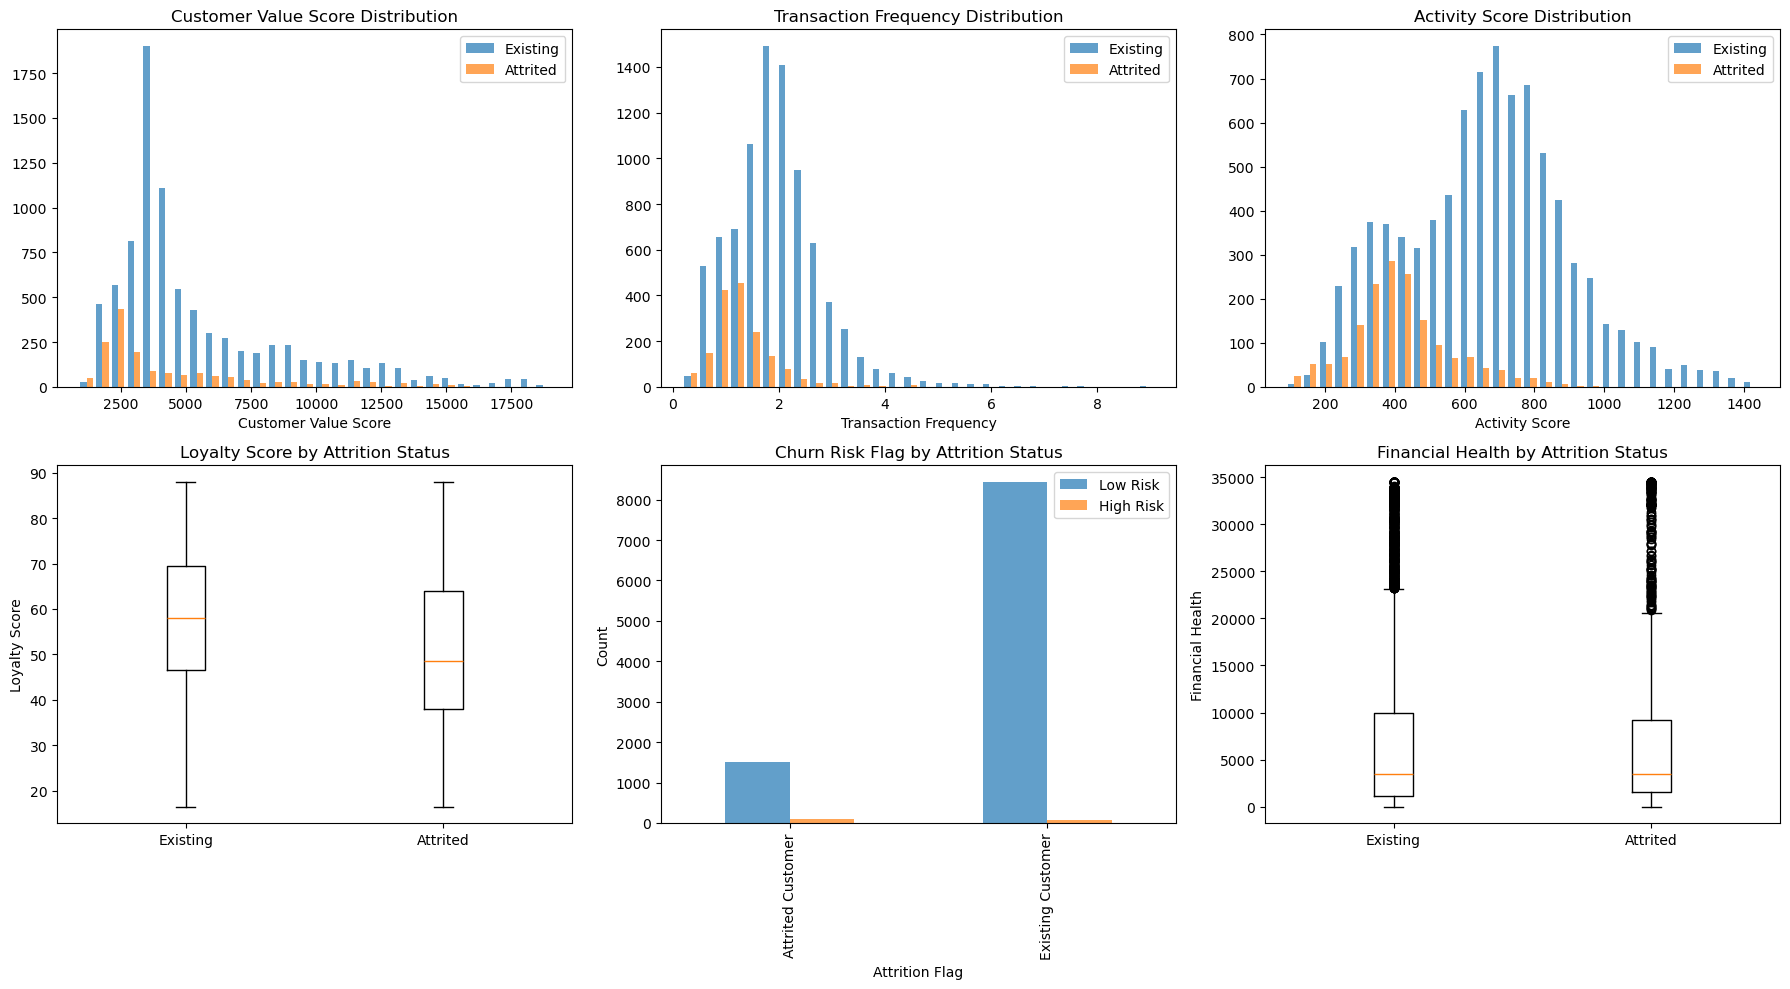

In [18]:
# VISUALIZE SOME KEY ENGINEERED FEATURES
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Customer Value Score by Attrition
axes[0, 0].hist([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Customer_Value_Score'],
                  df_fe[df_fe['Attrition_Flag']=='Attrited Customer']['Customer_Value_Score']],
                 label=['Existing', 'Attrited'], bins=30, alpha=0.7)
axes[0, 0].set_title('Customer Value Score Distribution')
axes[0, 0].set_xlabel('Customer Value Score')
axes[0, 0].legend()

# Plot 2: Transaction Frequency by Attrition
axes[0, 1].hist([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Transaction_Frequency'],
                  df_fe[df_fe['Attrition_Flag']=='Attrited Customer']['Transaction_Frequency']],
                 label=['Existing', 'Attrited'], bins=30, alpha=0.7)
axes[0, 1].set_title('Transaction Frequency Distribution')
axes[0, 1].set_xlabel('Transaction Frequency')
axes[0, 1].legend()

# Plot 3: Activity Score by Attrition
axes[0, 2].hist([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Activity_Score'],
                  df_fe[df_fe['Attrition_Flag']=='Attrited Customer']['Activity_Score']],
                 label=['Existing', 'Attrited'], bins=30, alpha=0.7)
axes[0, 2].set_title('Activity Score Distribution')
axes[0, 2].set_xlabel('Activity Score')
axes[0, 2].legend()

# Plot 4: Loyalty Score by Attrition
axes[1, 0].boxplot([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Loyalty_Score'],
                     df_fe[df_fe['Attrition_Flag']=='Attrited Customer']['Loyalty_Score']],
                    labels=['Existing', 'Attrited'])
axes[1, 0].set_title('Loyalty Score by Attrition Status')
axes[1, 0].set_ylabel('Loyalty Score')

# Plot 5: Churn Risk Flag
churn_risk_counts = df_fe.groupby(['Attrition_Flag', 'Churn_Risk_Flag']).size().unstack()
churn_risk_counts.plot(kind='bar', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Churn Risk Flag by Attrition Status')
axes[1, 1].set_xlabel('Attrition Flag')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(['Low Risk', 'High Risk'])

# Plot 6: Financial Health by Attrition
axes[1, 2].boxplot([df_fe[df_fe['Attrition_Flag']=='Existing Customer']['Financial_Health'],
                     df_fe[df_fe['Attrition_Flag']=='Attrited Customer']['Financial_Health']],
                    labels=['Existing', 'Attrited'])
axes[1, 2].set_title('Financial Health by Attrition Status')
axes[1, 2].set_ylabel('Financial Health')

plt.tight_layout()
plt.show()


<span style="font-family: monospace; font-size: 6mm;">

**Check for missing/inf values**

In [ ]:
print("Missing values in engineered dataset:")
missing_counts = df_fe.isnull().sum()
print(missing_counts[missing_counts > 0])

print("\nInfinity values check:")
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    inf_count = np.isinf(df_fe[col]).sum()
    if inf_count > 0:
        print(f"{col}: {inf_count} infinity values")
        
        df_fe[col].replace([np.inf, -np.inf], np.nan, inplace=True)
        df_fe[col].fillna(df_fe[col].median(), inplace=True)


Missing values in engineered dataset:
Series([], dtype: int64)

Infinity values check:


<span style="font-family: monospace; font-size: 6mm;">

ok i guess we good

<span style="font-family: monospace; font-size: 6mm;">

**Correlation Analysis**

Top 20 Features Most Positively Correlated with Attrition:
Attrition_Encoded               1.000000
Transaction_Consistency         0.355051
Contacts_Count_12_mon           0.204491
Contact_Rate                    0.204491
Open_To_Buy_Ratio               0.178318
Churn_Risk_Flag                 0.159705
Activity_Month                  0.156009
Inactive_Ratio                  0.152449
Months_Inactive_12_mon          0.152449
Activity_DayOfYear              0.151759
Balance_Efficiency              0.137077
Frequent_Contact_Flag           0.122743
Dependent_Relationship_Ratio    0.095824
Activity_WeekOfYear             0.091659
Credit_Per_Transaction          0.089531
Credit_Headroom                 0.083079
Activity_Quarter                0.064795
Low_Activity_Flag               0.064795
Education_Level_Encoded         0.019545
Dependent_count                 0.018991
dtype: float64

Top 20 Features Most Negatively Correlated with Attrition:
Account_Maturity           -0.129570
Total_Amt

c:\Users\PHUC\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\PHUC\anaconda3\envs\ml_env\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


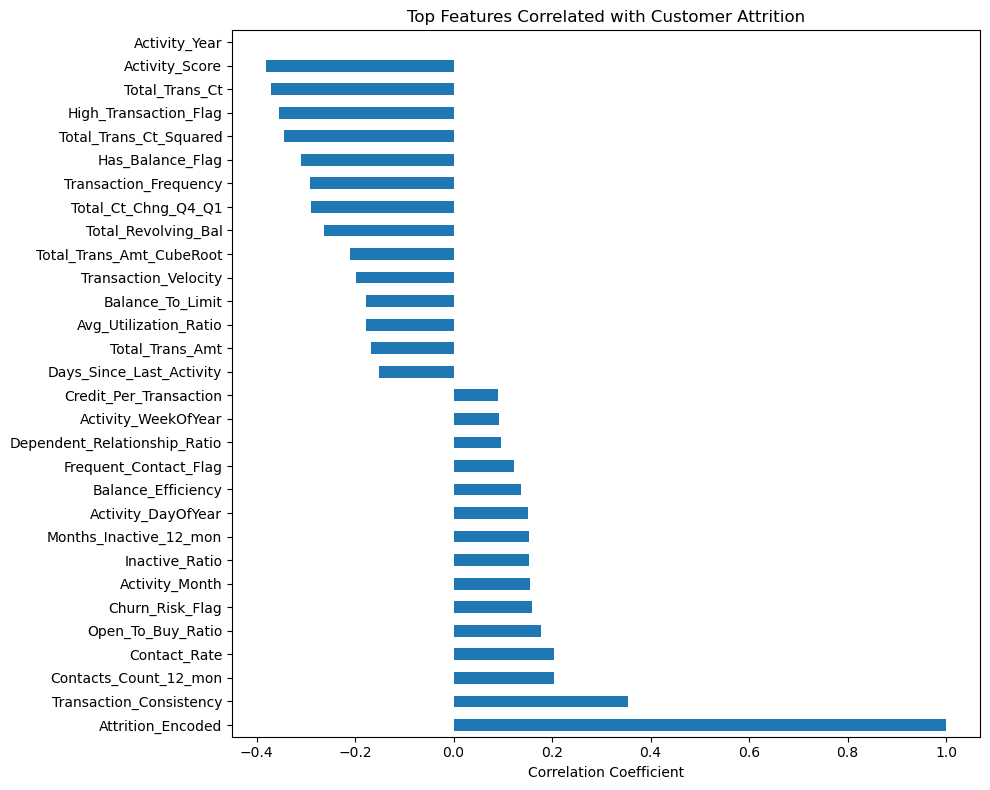

In [20]:
df_fe['Attrition_Encoded'] = (df_fe['Attrition_Flag'] == 'Attrited Customer').astype(int)

numeric_features = df_fe.select_dtypes(include=[np.number]).columns.tolist()

correlations = df_fe[numeric_features].corrwith(df_fe['Attrition_Encoded']).sort_values(ascending=False)

print("Top 20 Features Most Positively Correlated with Attrition:")
print(correlations.head(20))
print("\nTop 20 Features Most Negatively Correlated with Attrition:")
print(correlations.tail(20))

plt.figure(figsize=(12, 8))
top_features = pd.concat([correlations.head(15), correlations.tail(15)])
top_features.plot(kind='barh', figsize=(10, 8))
plt.title('Top Features Correlated with Customer Attrition')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [21]:
output_filename = 'BankChurners_Engineered.csv'
df_fe.to_csv(output_filename, index=False)
print(f"Engineered dataset saved to: {output_filename}")
print(f"Shape: {df_fe.shape}")
print(f"Total features: {df_fe.shape[1]}")
print(f"Total samples: {df_fe.shape[0]}")

Engineered dataset saved to: BankChurners_Engineered.csv
Shape: (10127, 77)
Total features: 77
Total samples: 10127


In [22]:
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio',
 'Credit_Per_Transaction',
 'Avg_Transaction_Amt',
 'Spending_To_Limit',
 'Relationship_Strength',
 'Activity_Score',
 'Engagement_Index',
 'Balance_To_Limit',
 'Open_To_Buy_Ratio',
 'Transaction_Frequency',
 'Contact_Rate',
 'Dependent_Relationship_Ratio',
 'Inactive_Ratio',
 'Credit_Limit_Squared',
 'Total_Trans_Amt_Squared',
 'Total_Trans_Ct_Squared',
 'Avg_Utilization_Ratio_Squared',
 'Credit_Limit_CubeRoot',
 'Total_Trans_Amt_CubeRoot',
 'Activity_Year',
 'Activity_Month',
 'Activity_Quarter',
 'Activity_DayOfWeek',
 'Activity_DayOfYear',
 'Activity_WeekOfYear',
 'Days_Since_Last_Activity',
 'Is_Weekend_Activity',
 'Loyalty_Score',
 'Financial_Health',
 'Transaction_Consist

In [32]:
# Xử lý outliers
cols_to_exclude = ['Attrition_Encoded']
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]

def cap_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound,
                        np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col]))
    return df_clean

df_capped = cap_outliers(df_fe, numeric_cols)

In [ ]:
# Scaling
scaler = StandardScaler()

df_scaled = df_capped.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_capped[numeric_cols])

In [36]:
# Feature Selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

corr_matrix = df_scaled[numeric_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"Số lượng features bị loại do tương quan cao: {len(to_drop)}")
print(f"Các features bị loại: {to_drop}")

X_filtered = df_scaled.drop(columns=to_drop)
X_numeric = X_filtered.select_dtypes(include=[np.number])

target_col = 'Attrition_Encoded'
y = df_fe[target_col]
X = X_numeric.drop(columns=[target_col], errors='ignore')

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

selector = SelectFromModel(rf, prefit=True, max_features=25)
selected_features = X.columns[selector.get_support()]

X_final = X[selected_features]

print(f"Số lượng features cuối cùng được chọn: {len(selected_features)}")
print("Danh sách features được chọn:", selected_features.tolist())

Số lượng features bị loại do tương quan cao: 23
Các features bị loại: ['Avg_Open_To_Buy', 'Credit_Per_Transaction', 'Activity_Score', 'Balance_To_Limit', 'Open_To_Buy_Ratio', 'Contact_Rate', 'Inactive_Ratio', 'Credit_Limit_Squared', 'Total_Trans_Amt_Squared', 'Total_Trans_Ct_Squared', 'Avg_Utilization_Ratio_Squared', 'Credit_Limit_CubeRoot', 'Total_Trans_Amt_CubeRoot', 'Activity_Month', 'Activity_DayOfYear', 'Activity_WeekOfYear', 'Days_Since_Last_Activity', 'Loyalty_Score', 'Financial_Health', 'Transaction_Consistency', 'High_Utilization_Flag', 'Account_Maturity', 'Credit_Headroom']
Số lượng features cuối cùng được chọn: 13
Danh sách features được chọn: ['Total_Relationship_Count', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Transaction_Amt', 'Transaction_Frequency', 'Balance_Efficiency', 'High_Transaction_Flag', 'Customer_Value_Score', 'Transaction_Velocity']
